# Description and objectives

This project uses a publicly available Kaggle dataset containing individual demographic, behavioral, and geographic characteristics (such as age, gender, BMI, number of dependents, smoking status, and region) to model medical insurance charges. The objective is to compare the predictive performance and inferential capacity of linear regression and decision tree models in estimating insurance premiums. While linear regression provides an interpretable parametric framework for identifying statistically significant drivers of healthcare costs, decision trees offer a flexible non-parametric alternative capable of capturing non-linear relationships and interaction effects. By evaluating both approaches, this project aims to assess their ability to explain and predict variation in medical insurance expenses.

In [321]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

df = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS, "willianoliveiragibin/healthcare-insurance", "insurance.csv")

df.head()

C:\Users\Santiago Gonz\AppData\Local\Temp\ipykernel_10160\3872367424.py:4: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS, "willianoliveiragibin/healthcare-insurance", "insurance.csv")


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


# Exploratory analysis 

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


C:\Users\Santiago Gonz\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


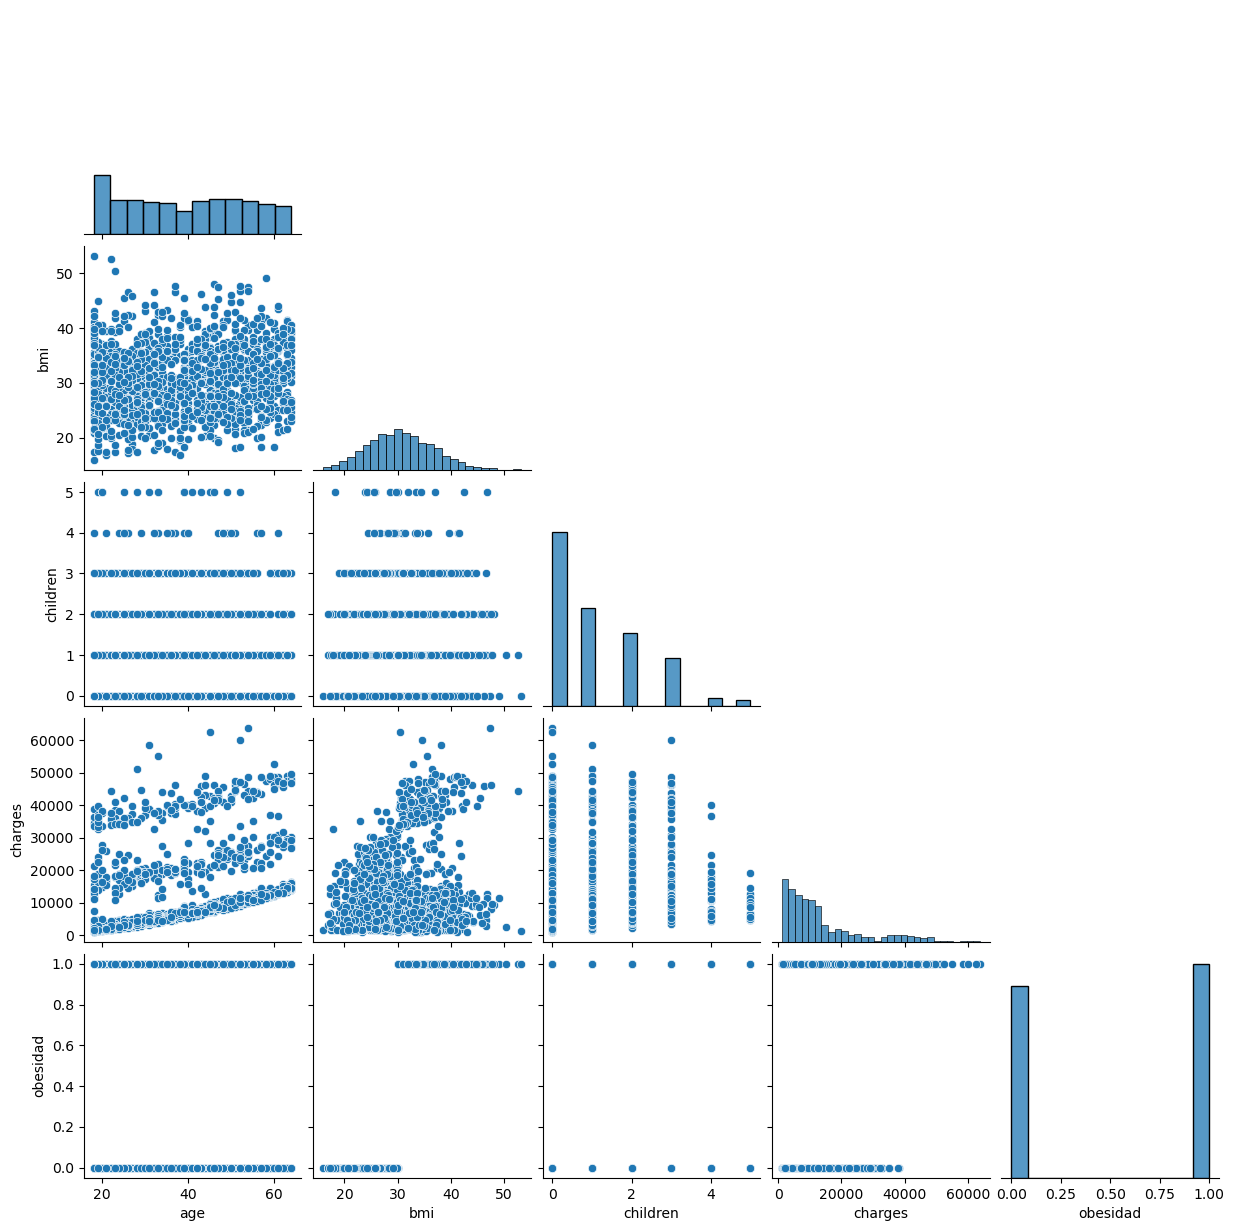

In [107]:
sns.pairplot(df, corner=True)

C:\Users\Santiago Gonz\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


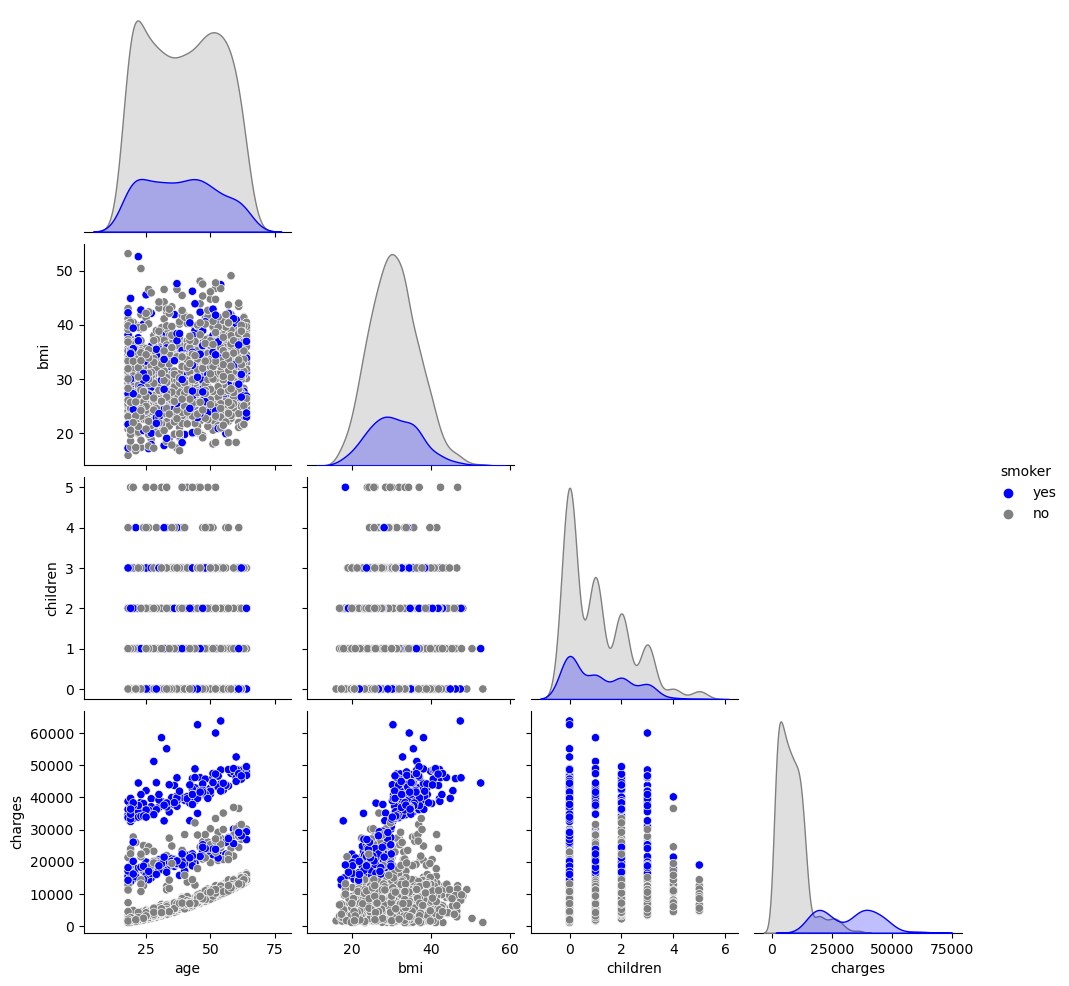

In [14]:
sns.pairplot(df, corner=True, hue='smoker', palette = {'no':'grey', 'yes':'b'})

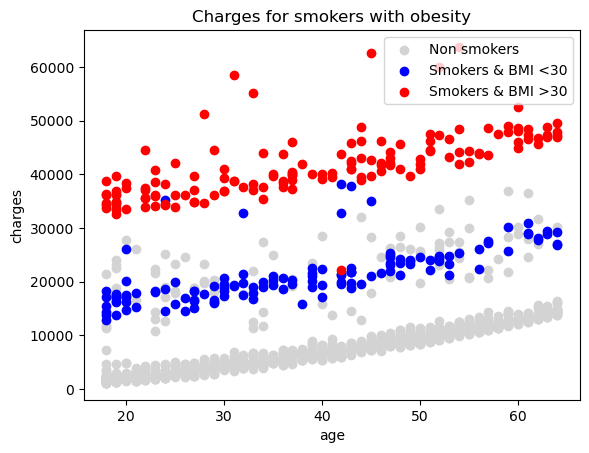

In [7]:
NoFumadores = df[df['smoker'] == 'no']
FumadoresObesos = df[(df['smoker'] == 'yes') & (df['bmi'] < 30)]
FumadoresNoObesos = df[(df['smoker'] == 'yes') & (df['bmi'] >= 30)]



plt.scatter(NoFumadores['age'], NoFumadores['charges'], label= 'Non smokers',color='lightgrey')
plt.scatter(FumadoresObesos['age'], FumadoresObesos['charges'], label= 'Smokers & BMI <30',color = 'blue')
plt.scatter(FumadoresNoObesos['age'], FumadoresNoObesos['charges'], label = 'Smokers & BMI >30', color = 'red')
plt.xlabel('age')
plt.ylabel('charges')
plt.legend()
plt.title('Charges for smokers with obesity')
plt.show()

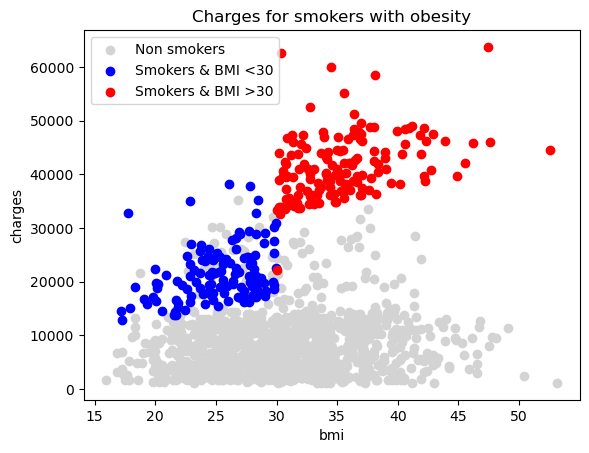

In [8]:
plt.scatter(NoFumadores['bmi'], NoFumadores['charges'], label='Non smokers', color= 'lightgrey')
plt.scatter(FumadoresObesos['bmi'], FumadoresObesos['charges'], label= 'Smokers & BMI <30', color='blue')
plt.scatter(FumadoresNoObesos['bmi'], FumadoresNoObesos['charges'], label = 'Smokers & BMI >30', color='red')
plt.xlabel('bmi')
plt.ylabel('charges')
plt.legend()
plt.title('Charges for smokers with obesity')
plt.show()

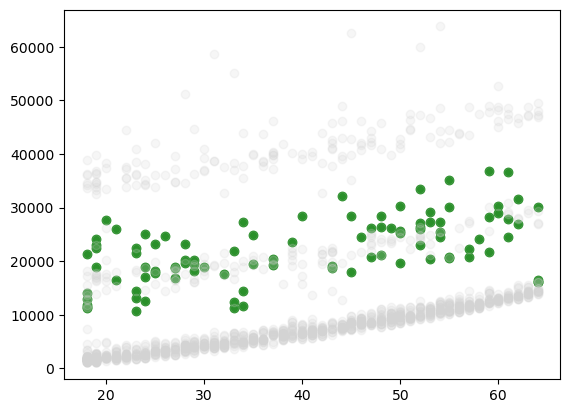

In [9]:
NoFumadoresCargosAltos = NoFumadores[((NoFumadores['charges'] > 10000) & (NoFumadores['age'] < 40)) | ((NoFumadores['charges'] > 16000) & (NoFumadores['age'] >= 40))]

plt.scatter(NoFumadoresCargosAltos['age'], NoFumadoresCargosAltos['charges'], alpha = 1, color='green')
plt.scatter(df['age'], df['charges'], alpha=0.2, color='lightgrey')

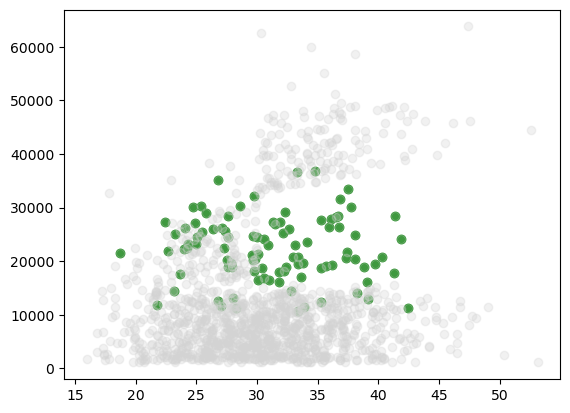

In [10]:
plt.scatter(NoFumadoresCargosAltos['bmi'], NoFumadoresCargosAltos['charges'], color='green', alpha = 1)
plt.scatter(df['bmi'], df['charges'], alpha=0.3, color='lightgrey')

During the exploratory analysis, we observed a strong interaction effect among smokers when their BMI exceeds 30, suggesting that the relationship between smoking status and medical charges becomes significantly amplified in the presence of obesity.

On the other hand, we also identified a subgroup of non-smokers (shown in green) with relatively high medical charges. However, this group does not appear to interact with any other observable continuous variables in the boxplots, which may indicate the presence of unobserved heterogeneity or omitted risk factors not captured in the current feature set.

# Train-test set

In [322]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(handle_unknown = 'ignore', drop = None, sparse_output = False).set_output(transform = 'pandas')

ohetransform = ohe.fit_transform(df[['region']])

df_encoded = pd.concat([df, ohetransform], axis =1)
df_encoded['sexdummy'] = (df_encoded['sex'] == 'male').astype(int)
df_encoded['smokerdummy'] = (df_encoded['smoker'] == 'yes').astype(int)

In [323]:
from sklearn.model_selection import train_test_split

# Variables independientes
X = df_encoded.drop(columns=['charges'])

# Variable dependiente
y = np.log(df_encoded['charges'])

X, X_test, y, y_test = train_test_split(X, y, test_size=0.2 ,random_state=42)

train_df = pd.concat([X, y], axis=1)
test_df  = pd.concat([X_test, y_test], axis=1)

# Linear regression

We initially fitted a linear regression model including all available predictors. The normality assumption of the residuals was reasonably satisfied; however, clear signs of heteroskedasticity were present. In particular, the residuals vs. fitted values plot revealed a curvature pattern below the fitted line and a distinct group of observations extending above it, suggesting potential model misspecification and non-linear effects not captured by the original specification.

Based on insights obtained during the exploratory analysis, we defined an obesity indicator variable for individuals with BMI > 30 and incorporated interaction terms between obesity status, age, and smoking status in order to account for potential non-linear relationships in medical charges.

After introducing these terms, we observed a substantial improvement in both the R² and AIC metrics, indicating a better model fit and a more parsimonious specification. The residual distribution remains sufficiently close to normal to support statistical inference on the estimated coefficients.

Nevertheless, heteroskedasticity persists within a subgroup of non-smokers exhibiting high medical charges. Given the available covariates, we lack sufficient information to fully explain the underlying dynamics of this group. This variability may be driven by factors unrelated to smoking behavior, such as genetic conditions or other chronic illnesses not captured in the dataset. Future models could benefit from incorporating additional clinical or behavioral variables to better account for this unexplained variance.

In [324]:
import statsmodels.formula.api as smf
import statsmodels.api as sm

In [325]:
formula = """charges ~ age
                     + C(smoker, Treatment(reference='no'))
                     + bmi
                     + C(sex, Treatment(reference='male'))
                     + C(children)
                     + C(region, Treatment(reference='southeast'))"""


model = smf.ols(formula, data=train_df).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                charges   R-squared:                       0.760
Model:                            OLS   Adj. R-squared:                  0.757
Method:                 Least Squares   F-statistic:                     278.5
Date:                Thu, 12 Feb 2026   Prob (F-statistic):          4.30e-317
Time:                        20:13:38   Log-Likelihood:                -655.78
No. Observations:                1070   AIC:                             1338.
Df Residuals:                    1057   BIC:                             1402.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
============================================================================================================================
                                                               coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------------------------
Intercept                                                    6.8156      0.091     75.190      0.000       6.638       6.993
C(smoker, Treatment(reference='no'))[T.yes]                  1.5546      0.034     45.272      0.000       1.487       1.622
C(sex, Treatment(reference='male'))[T.female]                0.0769      0.028      2.786      0.005       0.023       0.131
C(children)[T.1]                                             0.1339      0.035      3.821      0.000       0.065       0.203
C(children)[T.2]                                             0.2602      0.039      6.697      0.000       0.184       0.336
C(children)[T.3]                                             0.2067      0.045      4.555      0.000       0.118       0.296
C(children)[T.4]                                             0.4976      0.098      5.063      0.000       0.305       0.690
C(children)[T.5]                                             0.4128      0.118      3.488      0.001       0.181       0.645
C(region, Treatment(reference='southeast'))[T.northeast]     0.1398      0.040      3.525      0.000       0.062       0.218
C(region, Treatment(reference='southeast'))[T.northwest]     0.0789      0.040      1.974      0.049       0.000       0.157
C(region, Treatment(reference='southeast'))[T.southwest]     0.0144      0.039      0.370      0.711      -0.062       0.091
age                                                          0.0343      0.001     34.626      0.000       0.032       0.036
bmi                                                          0.0135      0.002      5.680      0.000       0.009       0.018
==============================================================================
Omnibus:                      351.598   Durbin-Watson:                   2.038
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1136.028
Skew:                           1.616   Prob(JB):                    2.06e-247
Kurtosis:                       6.877   Cond. No.                         447.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

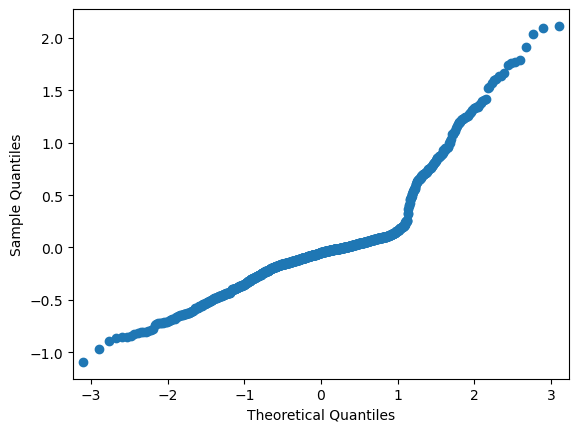

In [326]:
sm.qqplot(model.resid)
plt.show()

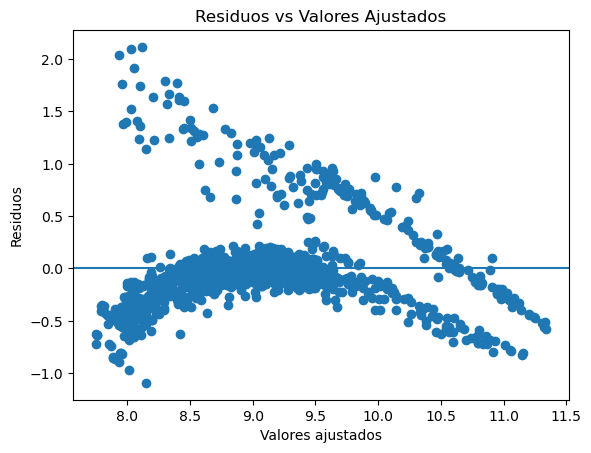

In [327]:
plt.scatter(model.fittedvalues, model.resid)
plt.axhline(0)
plt.xlabel("Valores ajustados")
plt.ylabel("Residuos")
plt.title("Residuos vs Valores Ajustados")
plt.show()

In [328]:
train_df['obesidad'] = (train_df['bmi'] > 30).astype(int)
test_df['obesidad'] = (test_df['bmi'] > 30).astype(int)

In [329]:
formula = """charges ~ age
                    + age:C(smoker, Treatment(reference='no'))
                    + C(sex)
                    + C(obesidad)
                    + C(smoker, Treatment(reference='no'))
                    + C(children, Treatment(reference=0))
                    + C(region, Treatment(reference='southeast'))
                    + C(smoker, Treatment(reference='no')):C(obesidad)"""

model = smf.ols(formula, data=train_df).fit()
model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                charges   R-squared:                       0.824
Model:                            OLS   Adj. R-squared:                  0.821
Method:                 Least Squares   F-statistic:                     352.2
Date:                Thu, 12 Feb 2026   Prob (F-statistic):               0.00
Time:                        20:13:40   Log-Likelihood:                -490.11
No. Observations:                1070   AIC:                             1010.
Df Residuals:                    1055   BIC:                             1085.
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
================================================================================================================================
                                                                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------------------------
Intercept                                                        7.0320      0.049    144.025      0.000       6.936       7.128
C(sex)[T.male]                                                  -0.0856      0.024     -3.612      0.000      -0.132      -0.039
C(obesidad)[T.1]                                                 0.0121      0.027      0.449      0.653      -0.041       0.065
C(smoker, Treatment(reference='no'))[T.yes]                      2.4730      0.089     27.911      0.000       2.299       2.647
C(children, Treatment(reference=0))[T.1]                         0.1629      0.030      5.413      0.000       0.104       0.222
C(children, Treatment(reference=0))[T.2]                         0.2760      0.033      8.270      0.000       0.210       0.341
C(children, Treatment(reference=0))[T.3]                         0.2424      0.039      6.217      0.000       0.166       0.319
C(children, Treatment(reference=0))[T.4]                         0.5174      0.084      6.142      0.000       0.352       0.683
C(children, Treatment(reference=0))[T.5]                         0.4616      0.101      4.549      0.000       0.262       0.661
C(region, Treatment(reference='southeast'))[T.northeast]         0.1140      0.033      3.410      0.001       0.048       0.180
C(region, Treatment(reference='southeast'))[T.northwest]         0.0562      0.034      1.664      0.096      -0.010       0.122
C(region, Treatment(reference='southeast'))[T.southwest]        -0.0420      0.033     -1.263      0.207      -0.107       0.023
C(smoker, Treatment(reference='no'))[T.yes]:C(obesidad)[T.1]     0.7136      0.059     12.133      0.000       0.598       0.829
age                                                              0.0414      0.001     43.696      0.000       0.040       0.043
age:C(smoker, Treatment(reference='no'))[T.yes]                 -0.0338      0.002    -16.117      0.000      -0.038      -0.030
==============================================================================
Omnibus:                      690.636   Durbin-Watson:                   2.079
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             6338.514
Skew:                           2.968   Prob(JB):                         0.00
Kurtosis:                      13.341   Cond. No.                         372.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

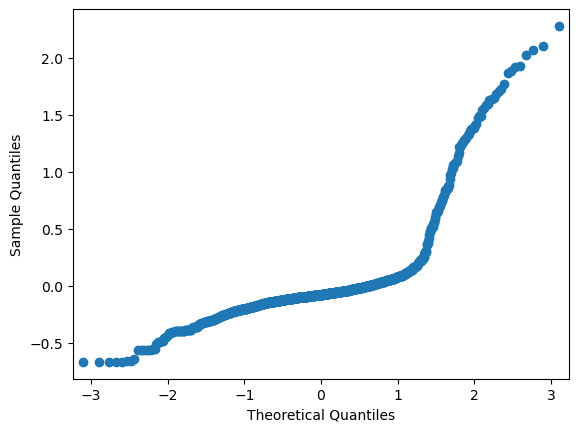

In [330]:
sm.qqplot(model.resid)
plt.show()

In [331]:
df['FumadoresCaros'] = (
    (df['smoker'] == 'no') &
    (((df['charges'] > 10000) & (df['age'] < 40)) |
    ((df['charges'] > 16000) & (df['age'] >= 40)))).astype(int)

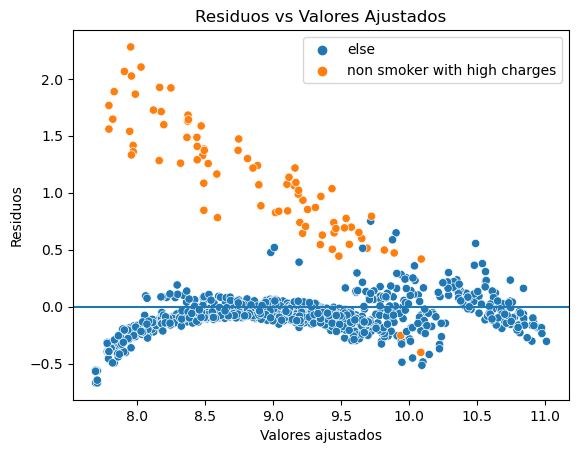

In [332]:
df['grupo_outlier'] = df['FumadoresCaros'].map({
    1: 'non smoker with high charges',
    0: 'else'
})

sns.scatterplot(
    x=model.fittedvalues,
    y=model.resid,
    hue=df['grupo_outlier']
)

plt.legend(title="")

plt.axhline(0)
plt.xlabel("Valores ajustados")
plt.ylabel("Residuos")
plt.title("Residuos vs Valores Ajustados")
plt.show()

In [333]:
# MSE train set

from sklearn.metrics import mean_squared_error

log_pred = model.predict(train_df)
mse_log = mean_squared_error(y, log_pred)

print("MSE (log scale):", mse_log)

MSE (log scale): 0.14634679128235328


In [334]:
# MSE test set

from sklearn.metrics import mean_squared_error

log_pred = model.predict(test_df)
mse_log = mean_squared_error(y_test, log_pred)

print("MSE (log scale):", mse_log)

MSE (log scale): 0.12855586740270283


# Decision tree

As a second modeling approach, we implemented a regression decision tree that uses cross-validation to identify the optimal tree structure through cost-complexity pruning. This procedure follows the algorithm presented by James et al. in Introduction to Statistical Learning for the construction of regression trees.

By applying cost-complexity pruning in combination with k-fold cross-validation, we are able to select a single tree that balances predictive performance and model complexity, thereby reducing the risk of overfitting while maintaining interpretability.

In [335]:
from sklearn.tree import DecisionTreeRegressor

tree = DecisionTreeRegressor(
    min_samples_leaf=3,
    random_state=42)

X = train_df[['age','sexdummy','bmi','children', 'smokerdummy', 'region_northeast', 'region_northwest',
       'region_southeast', 'region_southwest']]
y = train_df['charges']

tree = tree.fit(X,y)

In [336]:
# Con cost complexity pruning obtenemos una sucesión de árboles en función de alpha

random_state=42
min_leaf=3
path = tree.cost_complexity_pruning_path(X, y)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

# Por construcción, el último alpha colapsa el árbol a una sola hoja, por lo que se excluye como candidato de modelo.
if len(ccp_alphas) > 1:
    alphas_to_try = ccp_alphas[:-1]
    impurities_to_use = impurities[:-1]
else:
    alphas_to_try = ccp_alphas
    impurities_to_use = impurities

# Guardamos la sucesión en una lista
subtrees = []
for a in alphas_to_try:
    t = DecisionTreeRegressor(
        random_state=random_state,
        min_samples_leaf=min_leaf,
        ccp_alpha=a
    ).fit(X, y)
    subtrees.append(t)

In [337]:
# En cada sub-árbol hacemos K-fold cross validation y guardamos el MSE de los datos fuera del kth fold.
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

K = 5
kf = KFold(n_splits=K, shuffle=True, random_state=random_state)


cv_rows = []
for a in alphas_to_try:
    fold_mse = []
    for tr_idx, te_idx in kf.split(X, y):
        X_tr, X_te = X.iloc[tr_idx], X.iloc[te_idx]
        y_tr, y_te = y.iloc[tr_idx], y.iloc[te_idx]

        # Importante: re-ajustar el árbol en cada fold con el MISMO alpha
        model = DecisionTreeRegressor(
            random_state=random_state,
            min_samples_leaf=min_leaf,
            ccp_alpha=a
        )
        model.fit(X_tr, y_tr)
        y_hat = model.predict(X_te)
        fold_mse.append(mean_squared_error(y_te, y_hat))

    cv_rows.append({
        "ccp_alpha": float(a),
        "cv_mse_mean": float(np.mean(fold_mse)),
        "cv_mse_std": float(np.std(fold_mse)),
    })

cv_results = pd.DataFrame(cv_rows).sort_values("ccp_alpha").reset_index(drop=True)
cv_results.head()

,ccp_alpha,cv_mse_mean,cv_mse_std
0,0.000000e+00,0.200177,0.027322
1,8.829193e-08,0.200177,0.027322
2,1.827585e-07,0.200173,0.027324
3,2.114199e-07,0.200173,0.027324
4,2.153533e-07,0.200173,0.027324


In [338]:
# Elegimos el árbol que tenga el MSE promedio más bajo y entrenamos el modelo final con los datos completos

best_row = cv_results.loc[cv_results["cv_mse_mean"].idxmin()]
best_alpha = float(best_row["ccp_alpha"])

final_tree = DecisionTreeRegressor(
    random_state=random_state,
    min_samples_leaf=min_leaf,
    ccp_alpha=best_alpha
)
final_tree.fit(X, y)

DecisionTreeRegressor(ccp_alpha=0.002768504436291133, min_samples_leaf=3,
                      random_state=42)

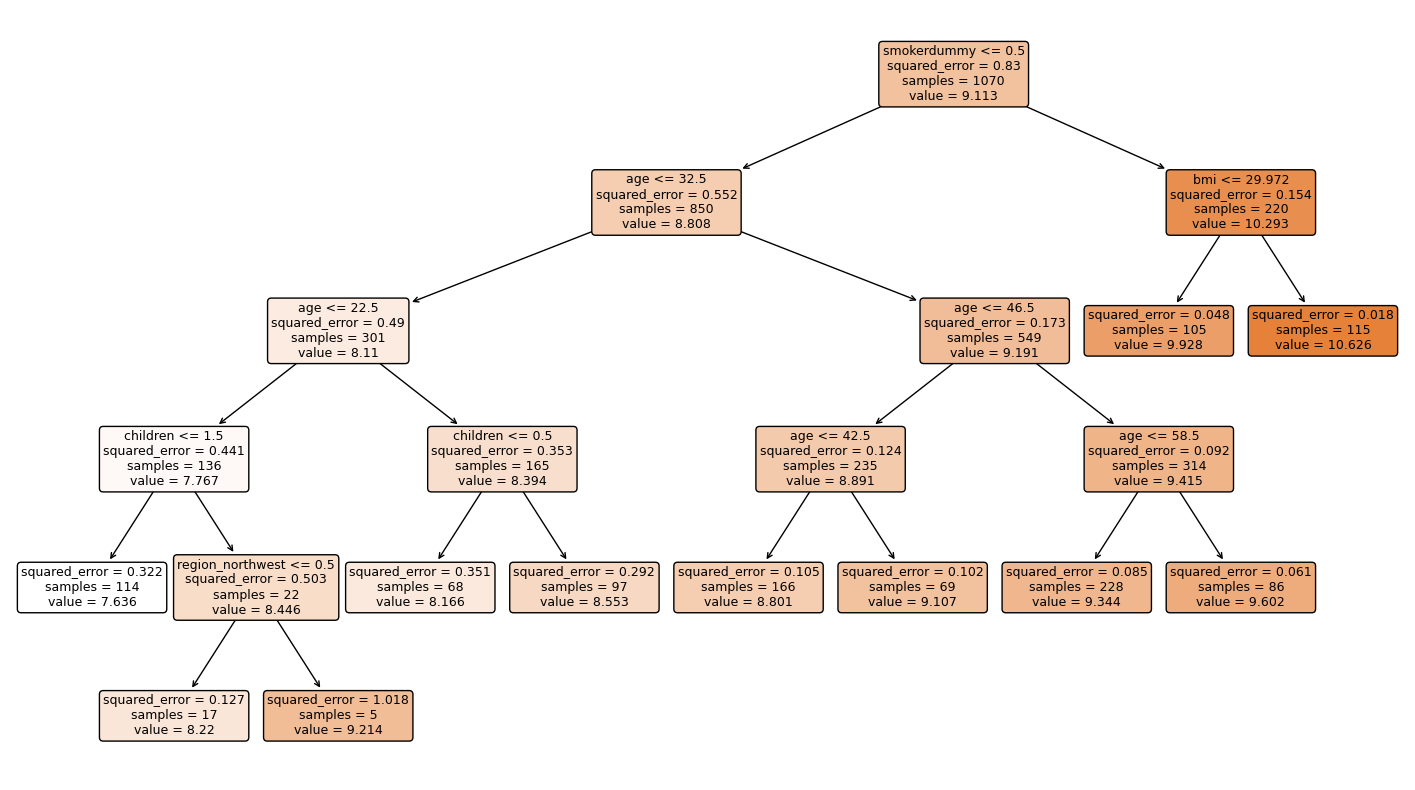

In [339]:
# Graficamos el árbol final completo
from sklearn.tree import plot_tree

plt.figure(figsize=(18, 10))
plot_tree(
    final_tree,
    feature_names= X.columns.tolist(),
    filled=True,
    rounded=True,
    fontsize=9
)
plt.show()

In [343]:
# MSE con train
y_pred = final_tree.predict(X)
train_mse = mean_squared_error(y, y_pred)

print("Train MSE (log):", train_mse)

Train MSE (log): 0.14255428332229644


In [344]:
# MSE con test

X_test_eval = test_df[['age','sexdummy','bmi','children', 
                       'smokerdummy', 'region_northeast', 
                       'region_northwest','region_southeast', 
                       'region_southwest']]

y_test_eval = test_df['charges']

y_pred = final_tree.predict(X_test_eval)
test_mse = mean_squared_error(y_test_eval, y_pred)

print("Test MSE (log):", test_mse)

Test MSE (log): 0.1364400234050431


# Conclusions

The linear regression results suggest that smoking status is the most significant factor associated with an increase in insurance premiums, followed by age and the number of dependents. In particular, being a smoker substantially increases expected medical charges, and this effect becomes significantly amplified when interacting with obesity status (BMI > 30), confirming the interaction pattern previously observed during the exploratory analysis. Age also has a positive and statistically significant effect on premiums; however, the negative interaction between age and smoking suggests that the marginal impact of aging is attenuated among smokers, likely due to already elevated baseline risk. Additionally, having children is consistently associated with higher premiums across all categories relative to individuals without dependents. Regional effects appear to be less economically significant, with only the northeast region showing a statistically meaningful increase relative to the southeast.

In terms of predictive performance, the linear regression model achieved a training MSE of 0.14634 and a test MSE of 0.1285 on the log-transformed scale, indicating good generalization performance. The regression tree slightly improved in-sample fit with a training MSE of 0.1425, although it exhibited a marginally higher test MSE of 0.1364. Importantly, the decision tree was also able to capture the joint dynamics between obesity and smoking status, suggesting that non-parametric approaches can effectively model interaction effects without requiring explicit specification. Overall, both models provide consistent evidence that the interaction between smoking behavior and obesity plays a critical role in determining insurance costs.